In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import sys
import json
import numpy as np

sys.path.append("/home/iscb/wolfson/hagairavid/ligand_alligner")
from utils.constants import NOT_ENOUGH_ATOMS_MESSAGE, TOO_MUCH_RESIDUES_MESSAGE, LIGAND_RESIDUE_IS_MISSED_MESSAGE, N_ATOMS_RATIO_MESSAGE
from utils.loading import deserialize_nested_lists

In [31]:
prefix = "2024-06-13_13-29-10"
directory = "/home/iscb/wolfson/hagairavid/ligand_alligner/baseline_results/"
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]

if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
df = pd.read_csv(file_path)


df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

# def str_to_list_of_lists(s):
#     try:
#         tuple_of_lists = ast.literal_eval(s)
#         list_of_lists = [list(sublist) for sublist in tuple_of_lists]
#         return list_of_lists
#     except:
#         return []
    
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).any():
        if col == 'p_rotations':
            print('here')
        df[col] = df[col].apply(lambda x: json.loads(x))
        df[col] = df[col].apply(lambda x: deserialize_nested_lists(x, col))



# df['coverage'] = df['coverage'].apply(str_to_list_of_lists)
# df['rmse'] = df['rmse'].apply(str_to_list_of_lists)
df

Latest file: /home/iscb/wolfson/hagairavid/ligand_alligner/baseline_results/2024-06-13_13-29-10_361.csv
here


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,...,mov_ligand_n_atoms,n_residues_ref_ligand,n_residues_mov_ligand,failure_message,p_rotations,p_translations,p_rmsd,p_coverage,p_message,rmsd
0,SAH,3cjt,5w7k,A,A,1,"[[[[-0.5980708 0.39594588 -0.69680566], [ 0....","[[[-13.149873733520508, 39.12715530395508, 62....",nan,nan,...,NaN,1,1,NaN,"[[[-0.6280188061489738, 0.2472570747556515, -0...","[[-21.858023109484513, 40.50911010828985, 58.3...",0.527697,NaN,NaN,11.071873
1,SAH,5log,5xoh,A,A,1,"[[[[-0.47258565 0.87504852 -0.10465613], [-0....","[[[-36.406829833984375, -78.08739471435547, -3...",nan,nan,...,NaN,1,1,NaN,"[[[-0.5895148372497282, 0.7356367774629026, -0...","[[-21.279698719369335, -87.91779173069582, -20...",0.578689,NaN,NaN,18.410309
2,SAH,3lby,7ux7,A,A,1,"[[[[ 0.61024052 -0.53712118 -0.58232927], [-0....","[[[9.688641548156738, 33.817256927490234, 40.1...",nan,nan,...,NaN,1,1,NaN,"[[[0.7704215742504594, -0.40218883251706083, -...","[[-7.167654598999245, 20.32233307591869, 31.59...",0.683223,NaN,NaN,9.780703
3,SAH,3g2p,4cng,A,A,3,"[[[[ 0.58930612 0.79190445 -0.16001767], [ 0....","[[[66.32298278808594, 104.23824310302734, 174....",nan,nan,...,NaN,1,2,NaN,"[[[0.358799812388231, -0.1421601836147949, 0.9...","[[-29.783246652245168, 186.196360922605, 111.4...",0.307927,NaN,NaN,203.244322
4,SAH,5bxy,7qos,A,A,1,"[[[[-0.19831564 0.20752327 0.95791698], [ 0....","[[[-2.9253177642822266, -8.641867637634277, 42...",nan,nan,...,NaN,1,1,NaN,"[[[-0.3517596965031058, 0.02355877523072406, 0...","[[0.9609402352735952, -5.258414213085679, 33.4...",0.798539,NaN,NaN,4.501323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,AZI,2bbr,6d4b,A,A,1,"[[[[ 0.94035733 -0.00957232 0.34005353], [ 0....","[[[-14.089617729187012, -30.11189079284668, 66...",nan,nan,...,NaN,1,1,NaN,"[[[0.5360035825689118, 0.04080791757511598, -0...","[[-41.54243678098271, -4.849177492560344, 12.3...",0.332934,NaN,NaN,106.303494
357,AZI,1a4e,1kop,A,A,1,"[[[[-0.76422572 -0.01992172 -0.64464116], [-0....","[[[145.9830780029297, 4.979344367980957, 37.97...",nan,nan,...,NaN,1,1,NaN,"[[[-0.36919254204543317, 0.20247322541732252, ...","[[163.8933436393244, 40.71296453560923, 39.217...",0.189357,NaN,NaN,22.599269
358,AZI,2j8m,7arz,A,A,4,"[[[[-0.70121872 -0.57084602 0.4271149 ], [-0....","[[[24.39982795715332, 20.287750244140625, 58.3...",nan,nan,...,NaN,2,2,NaN,"[[[0.12187547521145907, 0.9660585186900649, -0...","[[30.959140917845048, -21.275582873619584, 41....",0.340996,NaN,NaN,17.393049
359,AZI,3jtm,5edf,A,A,2,"[[[[0.7847175 0.37557319 0.49311578], [-0.491...","[[[8.943257331848145, 47.07183074951172, 24.49...",nan,nan,...,NaN,2,1,NaN,"[[[0.544321150279316, 0.8047753103091273, -0.2...","[[10.851442007472203, 8.503793220743912, 1.164...",0.222847,NaN,NaN,33.744243


## Number of transformations

Text(0.5, 1.0, 'Number of transformations')

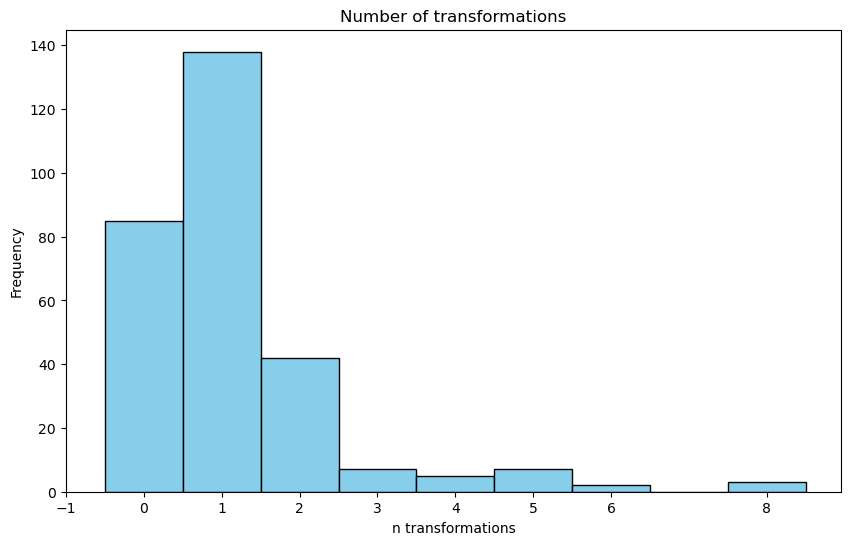

In [32]:
filtered_df = df[df['n_transformations'] < 10]
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['n_transformations'], bins= int(filtered_df['n_transformations'].max()) + 1, range=(0-0.5, filtered_df['n_transformations'].max()+0.5), color='skyblue', edgecolor='black')
plt.xticks(filtered_df['n_transformations'].unique())

# Adding labels and title

plt.xlabel('n transformations')
plt.ylabel('Frequency')
plt.title('Number of transformations')

#### Pairs with 2 clusters for specific ligand residues

In [33]:
def has_2_trans(values):
    for val in values:
        if len(val) == 2:
            return True
    return False

has_two_clusters = df['coverage'].apply(has_2_trans)
print(has_two_clusters.sum())
df[has_two_clusters].head()

0


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,...,mov_ligand_n_atoms,n_residues_ref_ligand,n_residues_mov_ligand,failure_message,p_rotations,p_translations,p_rmsd,p_coverage,p_message,rmsd


In [34]:
# filtered_df = df[df["failure message"].isna()]
df[df["n_transformations"] == 0]["failure_message"].value_counts()
no_trans = df[df["n_transformations"] == 0]
print(no_trans[no_trans["failure_message"].isna()].shape)
no_trans[no_trans["failure_message"].isna()].head()

(9, 22)


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,...,mov_ligand_n_atoms,n_residues_ref_ligand,n_residues_mov_ligand,failure_message,p_rotations,p_translations,p_rmsd,p_coverage,p_message,rmsd
195,CNA,1a26,6hxs,A,A,0,[[]],[[]],nan,nan,...,NaN,1,1,NaN,"[[[-0.5231156501706955, 0.8011849513750287, -0...","[[86.4013299184202, 26.275647270316448, 26.143...",0.479486,NaN,NaN,0.0
200,NAP,6t62,7y1u,A,A,0,[[]],[[]],nan,nan,...,NaN,1,1,NaN,"[[[-0.10552081274740173, -0.06341863009879388,...","[[49.72915683822542, 31.424112220034708, 69.27...",0.417717,NaN,NaN,0.0
201,NAP,1piw,6yc8,A,A,0,[[]],[[]],nan,nan,...,NaN,1,1,NaN,"[[[-0.3697833780560865, -0.9239399412627617, -...","[[186.382272258451, 109.19344336492341, 7.2480...",0.311133,NaN,NaN,0.0
207,NAP,1cd2,3wyc,A,A,0,[[]],[[]],nan,nan,...,NaN,1,1,NaN,"[[[0.6876731188438808, 0.7260169169146297, 0.0...","[[18.813828889995836, -47.216825598591655, 1.9...",0.371299,NaN,NaN,0.0
211,NAP,3jz4,8a3x,A,A,0,[[]],[[]],nan,nan,...,NaN,1,1,NaN,"[[[-0.41341642827223074, -0.705956637575033, -...","[[-28.92245014061377, 2.5796843444652815, -16....",0.255869,NaN,NaN,0.0


## DALI

In [ ]:
with_trans = df[df['n_transformations'] > 0]
with_trans['p_rmsd']=with_trans['p_rmsd'].apply(ast.literal_eval)
with_trans['found_dali'] = with_trans['p_rmsd'].apply(lambda x: len(x) > 0)

/tmp/ipykernel_586844/4202845500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['p_rmsd']=with_trans['p_rmsd'].apply(ast.literal_eval)
/tmp/ipykernel_586844/4202845500.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['found_dali'] = with_trans['p_rmsd'].apply(lambda x: len(x) > 0)


In [ ]:
with_trans[with_trans['found_dali'] == True]['cath_degree'].value_counts()

cath_degree
0    47
4    18
3     9
5     8
2     2
6     1
1     1
Name: count, dtype: int64

In [ ]:
with_trans[with_trans['found_dali'] == False]['cath_degree'].value_counts()

cath_degree
0    73
1    15
2    11
3     6
Name: count, dtype: int64

In [ ]:
df['cath_degree'].value_counts()

cath_degree
0    225
1     36
4     25
2     24
3     20
5      9
6      1
Name: count, dtype: int64

In [44]:
df[df['Ligand_ID'] == 'SAH'][['mov_protein', 'ref_protein', 'Ligand_ID', 'rmsd', 'cath_degree', 'n_transformations']]

,mov_protein,ref_protein,Ligand_ID,rmsd,cath_degree,n_transformations
0,5w7k,3cjt,SAH,11.071873,0,1
1,5xoh,5log,SAH,18.410309,4,1
2,7ux7,3lby,SAH,9.780703,0,1
3,4cng,3g2p,SAH,203.244322,2,3
4,7qos,5bxy,SAH,4.501323,0,1
5,7kff,6gkv,SAH,40.613912,0,1
6,7nzi,1mxi,SAH,181.162139,0,1
7,5wp4,5ex0,SAH,57.005283,0,2
8,6i71,1kpg,SAH,7.049449,0,1
9,3ua3,3bo5,SAH,48.943633,1,1
